In [1]:
# =============================================================================
# Extended analysis:
# NOR2/NOR4-adjacent methylation maps from Col-0 WT_rep2 WIG tracks
# -----------------------------------------------------------------------------
# Reads only from existing project folders:
#   ~/rDNA_repro/ref/
#   ~/rDNA_repro/raw/
#   ~/rDNA_repro/work/
#
# Writes only to:
#   ~/rDNA_repro/extended_analysis/
# =============================================================================

from pathlib import Path
import os
import re
import gzip
import tarfile
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PROJECT = Path.home() / "rDNA_repro"

RAW  = PROJECT / "raw"
REF  = PROJECT / "ref"
WORK = PROJECT / "work"

EXT = PROJECT / "extended_analysis"

EXT_WIG     = EXT / "wig"
EXT_TABLES  = EXT / "tables"
EXT_FIGURES = EXT / "figures"
EXT_LOGS    = EXT / "logs"

for d in [EXT, EXT_WIG, EXT_TABLES, EXT_FIGURES, EXT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

# Bin size for the 150 kb methylation heatmap.
# 500 bp gives a readable publication figure.
# Change to 50 if you specifically want 50 bp bins.
BIN_BP = 500

FORCE = False

# Set True only if the WT_rep2 WIG files are not already present locally.
# This downloads/extracts the processed GSE39901 WIG archive into extended_analysis only.
ALLOW_GEO_DOWNLOAD = True

print("[ok] Extended analysis setup ready")
print(f"[read] PROJECT: {PROJECT}")
print(f"[write] EXT:     {EXT}")
print(f"[info] BIN_BP:   {BIN_BP}")

[ok] Extended analysis setup ready
[read] PROJECT: /home/silieslab/rDNA_repro
[write] EXT:     /home/silieslab/rDNA_repro/extended_analysis
[info] BIN_BP:   500


In [2]:
# =============================================================================
# Read NOR2/NOR4 Geneious GenBank files
# -----------------------------------------------------------------------------
# Outputs:
#   extended_analysis/tables/NOR_region_lengths.csv
#   extended_analysis/tables/NOR_geneious_features.csv
# =============================================================================

try:
    from Bio import SeqIO
except ImportError as e:
    raise ImportError(
        "Biopython is required to parse Geneious GenBank files. "
        "Install it in your rDNA-meth environment with: conda install -c conda-forge biopython"
    ) from e

GB_FILES = {
    "NOR2": REF / "NOR2-flanking 150 kb.gb",
    "NOR4": REF / "NOR4-flanking 150 kb.gb",
}

for name, path in GB_FILES.items():
    assert path.exists(), f"Missing Geneious file for {name}: {path}"

region_lengths = []
feature_rows = []

def get_qual(feat, keys, default=""):
    for k in keys:
        if k in feat.qualifiers:
            v = feat.qualifiers[k]
            if isinstance(v, list):
                return str(v[0])
            return str(v)
    return default

def classify_feature(feat):
    q = feat.qualifiers
    txt = " ".join(
        str(x)
        for vals in q.values()
        for x in (vals if isinstance(vals, list) else [vals])
    ).lower()

    if feat.type in {"repeat_region", "mobile_element"}:
        return "TE"

    if "mobile_element" in txt or "retrotransposon" in txt or "transposon" in txt:
        return "TE"

    locus = get_qual(feat, ["locus_tag", "label", "ID"], "")
    if "TE" in locus:
        return "TE"

    if feat.type == "gene":
        return "gene"

    return None

for region_name, gb_path in GB_FILES.items():
    records = list(SeqIO.parse(str(gb_path), "genbank"))
    assert len(records) == 1, f"Expected one record in {gb_path}, found {len(records)}"

    rec = records[0]
    region_len = len(rec.seq)

    region_lengths.append({
        "region": region_name,
        "length_bp": region_len,
        "genbank_file": str(gb_path),
    })

    for feat in rec.features:
        kind = classify_feature(feat)
        if kind is None:
            continue

        start = int(feat.location.start) + 1
        end = int(feat.location.end)
        strand = feat.location.strand

        label = get_qual(
            feat,
            ["gene", "locus_tag", "label", "standard_name", "mobile_element_type", "ID"],
            default=feat.type,
        )

        # Keep labels clean.
        label = (
            label.replace("TAIR12_TAIR12_", "")
                 .replace("retrotransposon:", "")
                 .replace("transposon:", "")
        )

        feature_rows.append({
            "region": region_name,
            "kind": kind,
            "feature_type": feat.type,
            "start_bp": start,
            "end_bp": end,
            "length_bp": end - start + 1,
            "strand": strand,
            "label": label,
        })

length_df = pd.DataFrame(region_lengths)
features_df = pd.DataFrame(feature_rows)

length_path = EXT_TABLES / "NOR_region_lengths.csv"
features_path = EXT_TABLES / "NOR_geneious_features.csv"

length_df.to_csv(length_path, index=False)
features_df.to_csv(features_path, index=False)

display(length_df)
display(features_df.head())

print(f"[ok] Saved: {length_path}")
print(f"[ok] Saved: {features_path}")

,region,length_bp,genbank_file
0,NOR2,150097,/home/silieslab/rDNA_repro/ref/NOR2-flanking 1...
1,NOR4,150578,/home/silieslab/rDNA_repro/ref/NOR4-flanking 1...


,region,kind,feature_type,start_bp,end_bp,length_bp,strand,label
0,NOR2,TE,gene,1,2251,2251,-1,AT2TE00010
1,NOR2,TE,misc_feature,1,2251,2251,-1,mobile_genetic_element
2,NOR2,gene,gene,6,1709,1704,-1,AT2G01022
3,NOR2,TE,gene,2252,3026,775,-1,AT2TE90171
4,NOR2,TE,misc_feature,2252,3026,775,-1,mobile_genetic_element


[ok] Saved: /home/silieslab/rDNA_repro/extended_analysis/tables/NOR_region_lengths.csv
[ok] Saved: /home/silieslab/rDNA_repro/extended_analysis/tables/NOR_geneious_features.csv


In [3]:
# =============================================================================
# Locate WT_rep2 CG/CHG/CHH WIG files
# -----------------------------------------------------------------------------
# Preferred local filenames can be:
#   WT_rep2_CG.wig.gz
#   WT_rep2_CHG.wig.gz
#   WT_rep2_CHH.wig.gz
#
# Or GEO-prefixed names such as:
#   GSM980986_WT_rep2_CG.wig.gz
# =============================================================================

CONTEXTS = ["CG", "CHG", "CHH"]

SEARCH_DIRS = [
    RAW,
    WORK,
    EXT_WIG,
]

def find_wig_for_context(ctx):
    patterns = [
        f"*WT_rep2*{ctx}*.wig.gz",
        f"*WT*rep2*{ctx}*.wig.gz",
        f"*GSM980986*{ctx}*.wig.gz",
    ]

    hits = []
    for d in SEARCH_DIRS:
        if not d.exists():
            continue
        for pat in patterns:
            hits.extend(d.rglob(pat))

    hits = sorted(set(hits))

    if hits:
        return hits[0]

    return None

wig_paths = {ctx: find_wig_for_context(ctx) for ctx in CONTEXTS}

missing = [ctx for ctx, p in wig_paths.items() if p is None]

if missing and ALLOW_GEO_DOWNLOAD:
    print(f"[download] Missing WIG files for: {missing}")
    print("[download] Downloading GSE39901 processed WIG archive into extended_analysis only.")

    tar_path = EXT_WIG / "GSE39901_RAW.tar"
    geo_url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE39901&format=file"

    if not tar_path.exists():
        subprocess.run(
            ["wget", "-O", str(tar_path), geo_url],
            check=True,
        )
    else:
        print(f"[ok] GEO tar already exists: {tar_path}")

    with tarfile.open(tar_path, "r") as tar:
        members = tar.getmembers()
        names = [m.name for m in members]

        wanted = []
        for ctx in missing:
            candidates = [
                n for n in names
                if "WT_rep2" in Path(n).name and ctx in Path(n).name and n.endswith(".wig.gz")
            ]
            if not candidates:
                candidates = [
                    n for n in names
                    if "GSM980986" in Path(n).name and ctx in Path(n).name and n.endswith(".wig.gz")
                ]

            assert candidates, f"Could not find WT_rep2 {ctx} WIG inside GEO tar."

            wanted_name = candidates[0]
            wanted.append(wanted_name)
            print(f"[extract] {wanted_name}")

        tar.extractall(path=EXT_WIG, members=[m for m in members if m.name in wanted])

    wig_paths = {ctx: find_wig_for_context(ctx) for ctx in CONTEXTS}
    missing = [ctx for ctx, p in wig_paths.items() if p is None]

if missing:
    raise FileNotFoundError(
        "Missing WT_rep2 WIG files for contexts: "
        f"{missing}\n\n"
        "Either place the files in raw/, work/, or extended_analysis/wig/, "
        "or set ALLOW_GEO_DOWNLOAD = True in Cell 1."
    )

print("[ok] WIG files resolved:")
for ctx, p in wig_paths.items():
    print(f"  {ctx}: {p}")

[ok] WIG files resolved:
  CG: /home/silieslab/rDNA_repro/extended_analysis/wig/GSM980986_WT_rep2_CG.wig.gz
  CHG: /home/silieslab/rDNA_repro/extended_analysis/wig/GSM980986_WT_rep2_CHG.wig.gz
  CHH: /home/silieslab/rDNA_repro/extended_analysis/wig/GSM980986_WT_rep2_CHH.wig.gz


In [4]:
# =============================================================================
# Parse WT_rep2 WIG tracks and bin methylation over NOR2/NOR4 150 kb regions
# -----------------------------------------------------------------------------
# Outputs:
#   extended_analysis/tables/NOR_WT_rep2_binned_methylation_BIN500.csv
# =============================================================================

length_df = pd.read_csv(EXT_TABLES / "NOR_region_lengths.csv")

REGIONS = {
    "NOR2": {
        "chrom_aliases": {"2", "chr2", "chromosome2"},
        "start_bp": 1,
        "end_bp": int(length_df.loc[length_df["region"] == "NOR2", "length_bp"].iloc[0]),
    },
    "NOR4": {
        "chrom_aliases": {"4", "chr4", "chromosome4"},
        "start_bp": 1,
        "end_bp": int(length_df.loc[length_df["region"] == "NOR4", "length_bp"].iloc[0]),
    },
}

def clean_chrom(x):
    x = str(x).strip().lower()
    x = x.replace("chromosome", "chr")
    if x.startswith("chr"):
        return x
    return f"chr{x}"

for region in REGIONS.values():
    aliases = set(region["chrom_aliases"])
    aliases |= {clean_chrom(a) for a in aliases}
    region["chrom_aliases"] = aliases

def parse_wig_selected_regions(wig_path, context):
    rows = []

    current_chrom = None
    fixed_pos = None
    fixed_step = None

    with gzip.open(wig_path, "rt") as fh:
        for line in fh:
            line = line.strip()

            if not line or line.startswith("#") or line.startswith("track") or line.startswith("browser"):
                continue

            if line.startswith("variableStep"):
                m = re.search(r"chrom=([^\s]+)", line)
                current_chrom = clean_chrom(m.group(1)) if m else None
                fixed_pos = None
                fixed_step = None
                continue

            if line.startswith("fixedStep"):
                m_chrom = re.search(r"chrom=([^\s]+)", line)
                m_start = re.search(r"start=(\d+)", line)
                m_step = re.search(r"step=(\d+)", line)

                current_chrom = clean_chrom(m_chrom.group(1)) if m_chrom else None
                fixed_pos = int(m_start.group(1)) if m_start else None
                fixed_step = int(m_step.group(1)) if m_step else 1
                continue

            parts = line.split()

            if len(parts) == 2:
                pos = int(float(parts[0]))
                val = float(parts[1])
            elif len(parts) == 1 and fixed_pos is not None:
                pos = fixed_pos
                val = float(parts[0])
                fixed_pos += fixed_step
            else:
                continue

            for region_name, info in REGIONS.items():
                if current_chrom not in info["chrom_aliases"]:
                    continue

                if info["start_bp"] <= pos <= info["end_bp"]:
                    local_pos = pos - info["start_bp"] + 1
                    bin_start = ((local_pos - 1) // BIN_BP) * BIN_BP + 1
                    bin_end = min(bin_start + BIN_BP - 1, info["end_bp"])

                    rows.append({
                        "region": region_name,
                        "context": context,
                        "chrom": current_chrom,
                        "genomic_pos": pos,
                        "local_pos": local_pos,
                        "bin_start": bin_start,
                        "bin_end": bin_end,
                        "methylation": val,
                    })

    return pd.DataFrame(rows)

all_parts = []

for ctx, wig_path in wig_paths.items():
    print(f"[parse] {ctx}: {wig_path}")
    df = parse_wig_selected_regions(wig_path, ctx)
    print(f"        rows: {len(df):,}")

    if not df.empty:
        all_parts.append(df)

assert all_parts, "No methylation values were extracted. Check chromosome names and region coordinates."

meth_raw = pd.concat(all_parts, ignore_index=True)

# Some WIG tracks store methylation as 0–100 instead of 0–1.
if meth_raw["methylation"].max() > 1.5:
    print("[info] Detected methylation values >1. Scaling from percent to fraction.")
    meth_raw["methylation"] = meth_raw["methylation"] / 100.0

binned = (
    meth_raw.groupby(["region", "context", "bin_start", "bin_end"], as_index=False)
            .agg(
                methylation_fraction=("methylation", "mean"),
                cytosines=("methylation", "size"),
            )
)

raw_path = EXT_TABLES / "NOR_WT_rep2_raw_cytosine_methylation.csv"
bin_path = EXT_TABLES / f"NOR_WT_rep2_binned_methylation_BIN{BIN_BP}.csv"

meth_raw.to_csv(raw_path, index=False)
binned.to_csv(bin_path, index=False)

display(binned.head())

print(f"[ok] Saved raw cytosine table: {raw_path}")
print(f"[ok] Saved binned table:       {bin_path}")

[parse] CG: /home/silieslab/rDNA_repro/extended_analysis/wig/GSM980986_WT_rep2_CG.wig.gz
        rows: 11,548
[parse] CHG: /home/silieslab/rDNA_repro/extended_analysis/wig/GSM980986_WT_rep2_CHG.wig.gz
        rows: 11,279
[parse] CHH: /home/silieslab/rDNA_repro/extended_analysis/wig/GSM980986_WT_rep2_CHH.wig.gz
        rows: 43,635


,region,context,bin_start,bin_end,methylation_fraction,cytosines
0,NOR2,CG,1001,1500,0.053964,57
1,NOR2,CG,1501,2000,-0.196903,25
2,NOR2,CG,2001,2500,-0.152648,19
3,NOR2,CG,2501,3000,0.063651,33
4,NOR2,CG,3001,3500,-0.360900,27


[ok] Saved raw cytosine table: /home/silieslab/rDNA_repro/extended_analysis/tables/NOR_WT_rep2_raw_cytosine_methylation.csv
[ok] Saved binned table:       /home/silieslab/rDNA_repro/extended_analysis/tables/NOR_WT_rep2_binned_methylation_BIN500.csv


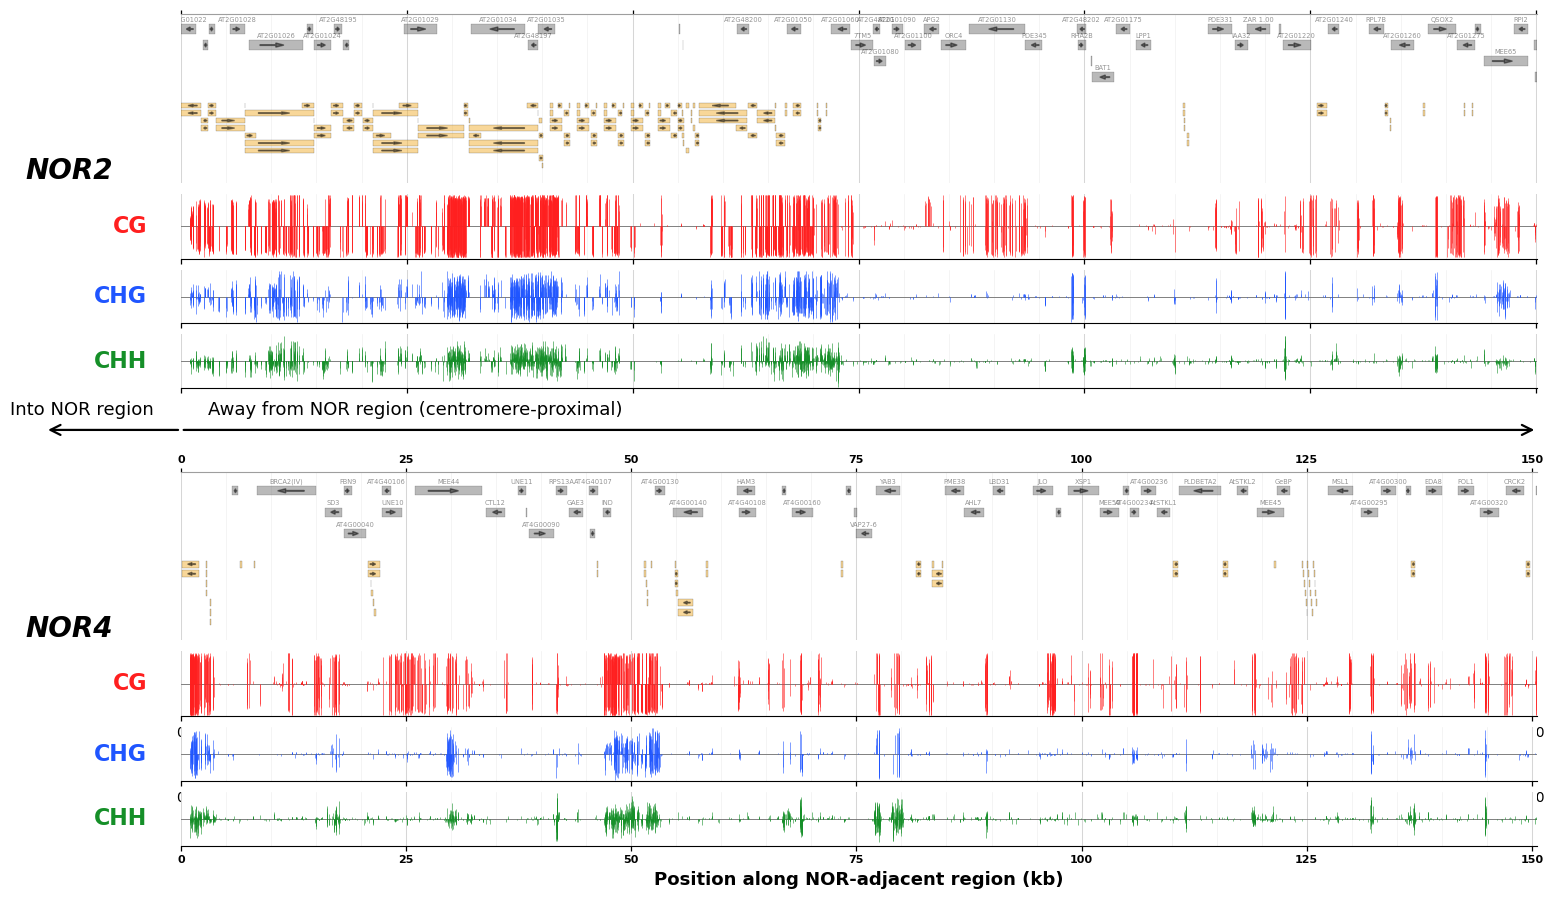

[ok] Saved updated JBrowse-style figure:
     /home/silieslab/rDNA_repro/extended_analysis/figures/NOR2_NOR4_WT_rep2_JBrowse_style_tracks_v3.png
     /home/silieslab/rDNA_repro/extended_analysis/figures/NOR2_NOR4_WT_rep2_JBrowse_style_tracks_v3.svg


In [5]:
# =============================================================================
# JBrowse-style NOR2/NOR4 methylation browser tracks - updated version 3
# -----------------------------------------------------------------------------
# Updates:
#   - No "Genes" and "TEs" labels
#   - Gene/TE names are faint and not bold
#   - NOR2/NOR4 labels placed above CG tracks
#   - More space above and below direction arrows
#   - "Into NOR region" arrow starts at 0 and points left, like original figure
#
# Reads:
#   extended_analysis/tables/NOR_WT_rep2_raw_cytosine_methylation.csv
#   extended_analysis/tables/NOR_geneious_features.csv
#   extended_analysis/tables/NOR_region_lengths.csv
#
# Writes:
#   extended_analysis/figures/NOR2_NOR4_WT_rep2_JBrowse_style_tracks_v3.png
#   extended_analysis/figures/NOR2_NOR4_WT_rep2_JBrowse_style_tracks_v3.svg
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
PROJECT = Path.home() / "rDNA_repro"
EXT = PROJECT / "extended_analysis"
EXT_TABLES = EXT / "tables"
EXT_FIGURES = EXT / "figures"
EXT_FIGURES.mkdir(parents=True, exist_ok=True)

raw_path = EXT_TABLES / "NOR_WT_rep2_raw_cytosine_methylation.csv"
features_path = EXT_TABLES / "NOR_geneious_features.csv"
length_path = EXT_TABLES / "NOR_region_lengths.csv"

assert raw_path.exists(), f"Missing {raw_path}. Run the WIG parsing cell first."
assert features_path.exists(), f"Missing {features_path}. Run the GenBank annotation cell first."
assert length_path.exists(), f"Missing {length_path}. Run the GenBank annotation cell first."

out_png = EXT_FIGURES / "NOR2_NOR4_WT_rep2_JBrowse_style_tracks_v3.png"
out_svg = EXT_FIGURES / "NOR2_NOR4_WT_rep2_JBrowse_style_tracks_v3.svg"

FORCE = globals().get("FORCE", False)

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
raw = pd.read_csv(raw_path)
features = pd.read_csv(features_path)
length_df = pd.read_csv(length_path)

region_lengths = dict(zip(length_df["region"], length_df["length_bp"]))

# ---------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "svg.fonttype": "none",
})

COLORS = {
    "CG":  "#ff1f1f",
    "CHG": "#1f55ff",
    "CHH": "#158f28",
    "gene": "#5a5a5a",
    "TE": "#f2b134",
}

PUB = {
    "region": 20,
    "track": 16,
    "axis": 13,
    "tick": 8,
    "feature": 4.8,
}

REGION_ORDER = ["NOR2", "NOR4"]

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def clean_feature_label(x):
    x = str(x)
    x = x.replace("TAIR12_TAIR12_", "")
    x = x.replace("retrotransposon:", "")
    x = x.replace("transposon:", "")
    x = x.replace("gene:", "")
    return x.strip()

def add_browser_grid(ax, region_len_kb, major=25, minor=5):
    minor_ticks = np.arange(0, region_len_kb + minor, minor)
    major_ticks = np.arange(0, region_len_kb + major, major)

    for x in minor_ticks:
        ax.axvline(x, color="#eeeeee", lw=0.45, zorder=0)

    for x in major_ticks:
        ax.axvline(x, color="#d6d6d6", lw=0.75, zorder=0)

def assign_lanes(df, gap_kb=0.8):
    df = df.sort_values(["start_bp", "end_bp"]).copy()
    lane_ends = []
    lanes = []

    for _, r in df.iterrows():
        start = float(r["start_bp"]) / 1000
        end = float(r["end_bp"]) / 1000

        placed = False

        for i, last_end in enumerate(lane_ends):
            if start > last_end + gap_kb:
                lanes.append(i)
                lane_ends[i] = end
                placed = True
                break

        if not placed:
            lanes.append(len(lane_ends))
            lane_ends.append(end)

    df["lane"] = lanes
    return df

def draw_feature_arrow(ax, x0, x1, y, h, strand, color, alpha=0.45):
    width = max(x1 - x0, 0.03)

    ax.add_patch(
        Rectangle(
            (x0, y),
            width,
            h,
            facecolor=color,
            edgecolor="black",
            lw=0.25,
            alpha=alpha,
            zorder=3,
        )
    )

    try:
        strand = int(strand)
    except Exception:
        strand = 0

    if width < 0.35:
        return

    arrow_y = y + h / 2
    arrow_len = width * 0.45
    head_len = min(width * 0.25, 0.9)

    if strand == 1:
        ax.add_patch(
            FancyArrow(
                x0 + width * 0.20,
                arrow_y,
                arrow_len,
                0,
                width=0.004,
                head_width=h * 0.45,
                head_length=head_len,
                length_includes_head=True,
                color="black",
                alpha=0.45,
                zorder=4,
            )
        )

    elif strand == -1:
        ax.add_patch(
            FancyArrow(
                x1 - width * 0.20,
                arrow_y,
                -arrow_len,
                0,
                width=0.004,
                head_width=h * 0.45,
                head_length=head_len,
                length_includes_head=True,
                color="black",
                alpha=0.45,
                zorder=4,
            )
        )

def draw_annotation_panel(ax, region):
    region_len = region_lengths[region]
    region_len_kb = region_len / 1000

    ax.set_xlim(0, region_len_kb)
    ax.set_ylim(0, 1)
    ax.set_facecolor("white")

    add_browser_grid(ax, region_len_kb)

    for side in ["left", "right", "bottom"]:
        ax.spines[side].set_visible(False)

    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_linewidth(0.8)
    ax.spines["top"].set_color("#9e9e9e")

    ax.set_yticks([])

    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    xticks = np.arange(0, region_len_kb + 1, 25)
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [f"{int(x):,}" if x > 0 else "0" for x in xticks],
        fontsize=PUB["tick"],
        fontweight="bold",
    )

    sub = features[features["region"] == region].copy()

    genes = assign_lanes(sub[sub["kind"] == "gene"].copy(), gap_kb=1.0)
    tes = assign_lanes(sub[sub["kind"] == "TE"].copy(), gap_kb=0.4)

    # Gene lanes occupy upper part.
    gene_lane_count = max(1, int(genes["lane"].max() + 1)) if len(genes) else 1
    gene_top = 0.96
    gene_bottom = 0.58
    gene_step = (gene_top - gene_bottom) / gene_lane_count
    gene_h = min(0.055, gene_step * 0.65)

    for _, r in genes.iterrows():
        x0 = float(r["start_bp"]) / 1000
        x1 = float(r["end_bp"]) / 1000
        lane = int(r["lane"])

        y = gene_top - (lane + 1) * gene_step + gene_step * 0.2

        draw_feature_arrow(
            ax=ax,
            x0=x0,
            x1=x1,
            y=y,
            h=gene_h,
            strand=r.get("strand", 0),
            color=COLORS["gene"],
            alpha=0.42,
        )

        label = clean_feature_label(r["label"])
        width = x1 - x0

        if width >= 0.8:
            ax.text(
                x0 + width / 2,
                y + gene_h + 0.008,
                label,
                ha="center",
                va="bottom",
                fontsize=PUB["feature"],
                fontweight="normal",
                color="black",
                alpha=0.42,
                clip_on=True,
                zorder=5,
            )

    # TE lanes occupy lower part.
    te_lane_count = max(1, int(tes["lane"].max() + 1)) if len(tes) else 1
    te_top = 0.48
    te_bottom = 0.08
    te_step = (te_top - te_bottom) / te_lane_count
    te_h = min(0.065, te_step * 0.70)

    for _, r in tes.iterrows():
        x0 = float(r["start_bp"]) / 1000
        x1 = float(r["end_bp"]) / 1000
        lane = int(r["lane"])

        y = te_top - (lane + 1) * te_step + te_step * 0.15

        draw_feature_arrow(
            ax=ax,
            x0=x0,
            x1=x1,
            y=y,
            h=te_h,
            strand=r.get("strand", 0),
            color=COLORS["TE"],
            alpha=0.50,
        )

def draw_methylation_track(ax, region, context, show_x=False):
    region_len = region_lengths[region]
    region_len_kb = region_len / 1000

    ax.set_xlim(0, region_len_kb)
    ax.set_ylim(-1.05, 1.05)
    ax.set_facecolor("white")

    add_browser_grid(ax, region_len_kb)

    ax.axhline(0, color="#777777", lw=0.65, zorder=1)

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.set_yticks([])

    sub = raw[
        (raw["region"] == region) &
        (raw["context"] == context)
    ].copy()

    if not sub.empty:
        x = sub["local_pos"].to_numpy(dtype=float) / 1000.0
        y = sub["methylation"].to_numpy(dtype=float)

        if np.nanmin(y) >= 0:
            y_abs = np.clip(np.abs(y), 0, 1)
            ymin = -y_abs
            ymax = y_abs
        else:
            y = np.clip(y, -1, 1)
            ymin = np.minimum(0, y)
            ymax = np.maximum(0, y)

        ax.vlines(
            x,
            ymin,
            ymax,
            color=COLORS[context],
            linewidth=0.42,
            alpha=0.95,
            zorder=3,
        )

    ax.text(
        -0.025,
        0.5,
        context,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=PUB["track"],
        fontweight="bold",
        color=COLORS[context],
    )

    if show_x:
        xticks = np.arange(0, region_len_kb + 1, 25)
        ax.set_xticks(xticks)
        ax.set_xticklabels(
            [f"{int(x)}" if x > 0 else "0" for x in xticks],
            fontsize=PUB["tick"],
            fontweight="bold",
        )
        ax.set_xlabel(
            "Position along NOR-adjacent region (kb)",
            fontsize=PUB["axis"],
            fontweight="bold",
        )
    else:
        ax.set_xticklabels([])

def add_region_label_above_cg(ax, region):
    ax.text(
        -0.05,
        1.34,
        region,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=PUB["region"],
        fontweight="bold",
        fontstyle="italic",
        color="black",
        clip_on=False,
    )

def draw_direction_axis(ax):
    ax.set_xlim(-0.12, 1.0)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Left arrow: starts at 0 and points into NOR region, i.e. left of zero.
    ax.annotate(
        "",
        xy=(-0.10, 0.50),
        xytext=(0.00, 0.50),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.6,
            color="black",
            mutation_scale=18,
        ),
    )

    # Right arrow: away from NOR region.
    ax.annotate(
        "",
        xy=(1.00, 0.50),
        xytext=(0.00, 0.50),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.6,
            color="black",
            mutation_scale=18,
        ),
    )

    ax.text(
        -0.02,
        0.82,
        "Into NOR region",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=PUB["axis"],
        fontweight="normal",
        clip_on=False,
    )

    ax.text(
        0.02,
        0.82,
        "Away from NOR region (centromere-proximal)",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=PUB["axis"],
        fontweight="normal",
    )

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
if out_png.exists() and out_svg.exists() and not FORCE:
    print("[ok] Updated JBrowse-style figure already exists, skipping:")
    print(f"     {out_png}")
    print(f"     {out_svg}")

else:
    fig = plt.figure(figsize=(17.5, 10.8))

    gs = fig.add_gridspec(
        nrows=9,
        ncols=1,
        height_ratios=[
            1.50, 0.58, 0.48, 0.48,
            0.55,
            1.50, 0.58, 0.48, 0.48,
        ],
        hspace=0.13,
    )

    # -------------------------
    # NOR2
    # -------------------------
    region = "NOR2"

    ax_ann2 = fig.add_subplot(gs[0, 0])
    draw_annotation_panel(ax_ann2, region)

    ax_cg2 = fig.add_subplot(gs[1, 0], sharex=ax_ann2)
    draw_methylation_track(ax_cg2, region, "CG", show_x=False)
    add_region_label_above_cg(ax_cg2, "NOR2")

    ax_chg2 = fig.add_subplot(gs[2, 0], sharex=ax_ann2)
    draw_methylation_track(ax_chg2, region, "CHG", show_x=False)

    ax_chh2 = fig.add_subplot(gs[3, 0], sharex=ax_ann2)
    draw_methylation_track(ax_chh2, region, "CHH", show_x=False)

    ax_dir = fig.add_subplot(gs[4, 0])
    draw_direction_axis(ax_dir)

    # -------------------------
    # NOR4
    # -------------------------
    region = "NOR4"

    ax_ann4 = fig.add_subplot(gs[5, 0])
    draw_annotation_panel(ax_ann4, region)

    ax_cg4 = fig.add_subplot(gs[6, 0], sharex=ax_ann4)
    draw_methylation_track(ax_cg4, region, "CG", show_x=False)
    add_region_label_above_cg(ax_cg4, "NOR4")

    ax_chg4 = fig.add_subplot(gs[7, 0], sharex=ax_ann4)
    draw_methylation_track(ax_chg4, region, "CHG", show_x=False)

    ax_chh4 = fig.add_subplot(gs[8, 0], sharex=ax_ann4)
    draw_methylation_track(ax_chh4, region, "CHH", show_x=True)

    for ax in [ax_ann2, ax_ann4]:
        ax.tick_params(axis="x", length=3, pad=2)

    plt.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("[ok] Saved updated JBrowse-style figure:")
    print(f"     {out_png}")
    print(f"     {out_svg}")